# 05 — Evaluation & XAI
Metrics, residual plots and SHAP feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

X_test   = pd.read_csv('../data/processed/X_test.csv')
y_test   = pd.read_csv('../data/processed/y_test.csv').squeeze()   # log-scale
model    = joblib.load('../models/rent_pipeline.pkl')
pred_log = model.predict(X_test)
pred     = np.expm1(pred_log)   # back to CHF
y_orig   = np.expm1(y_test)
print('Model loaded.')

Model loaded.


In [2]:
mae  = mean_absolute_error(y_orig, pred)
rmse = root_mean_squared_error(y_orig, pred)
r2   = r2_score(y_orig, pred)
print(f'MAE:  {mae:.2f} CHF')
print(f'RMSE: {rmse:.2f} CHF')
print(f'R2:   {r2:.3f}')

MAE:  51.38 CHF
RMSE: 100.00 CHF
R2:   0.458


In [3]:
import json, os

metrics = {'MAE_CHF': round(mae, 2), 'RMSE_CHF': round(rmse, 2), 'R2': round(r2, 3)}
os.makedirs('../reports', exist_ok=True)
with open('../reports/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved reports/metrics.json:', metrics)

Saved reports/metrics.json: {'MAE_CHF': 51.38, 'RMSE_CHF': 100.0, 'R2': 0.458}


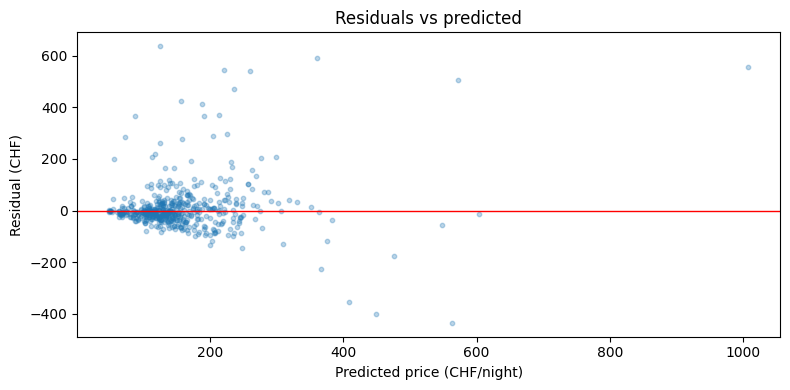

In [4]:
residuals = y_orig - pred
plt.figure(figsize=(8, 4))
plt.scatter(pred, residuals, alpha=0.3, s=10)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted price (CHF/night)')
plt.ylabel('Residual (CHF)')
plt.title('Residuals vs predicted')
plt.tight_layout()
plt.savefig('../reports/figures/residuals.png', dpi=150)
plt.show()

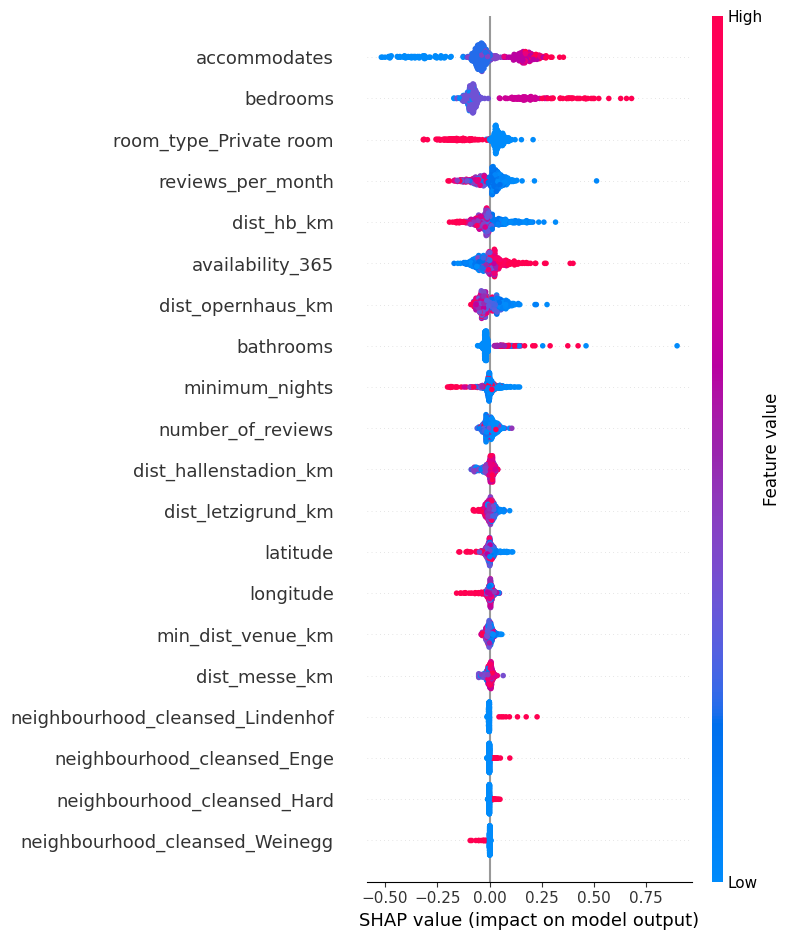

In [5]:
# SHAP
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

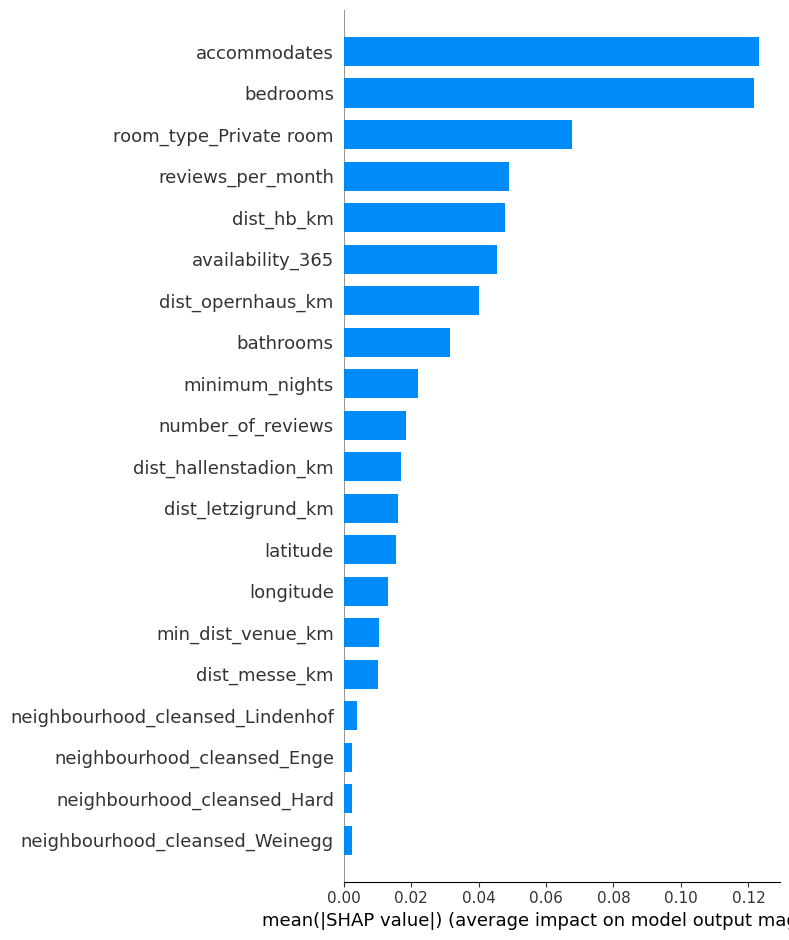

In [6]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## AI Reflection

### What AI tools were used and how

We used Claude and GitHub Copilot during this project. Copilot was active in VS Code and autocompleted boilerplate pandas/sklearn code — primarily repetitive patterns like column selection, `get_dummies`, and `train_test_split` calls. Claude was used for two specific tasks: (1) debugging the price-column string-to-float conversion (`$232.00` format) after we encountered a type error, and (2) generating the initial SHAP integration snippet because neither of us had used `shap.TreeExplainer` before.

### What we verified manually

Every line the AI suggested that touched the data or the model was checked against the pandas/sklearn documentation before being accepted. In particular:
- We verified that `drop_first=True` in `get_dummies` was correct for our regression setting (avoids the dummy-variable trap).
- We checked that `scaler.fit_transform` was applied only to `X_train` and `scaler.transform` (not fit) to `X_test`, to prevent data leakage.
- We confirmed that the SHAP `TreeExplainer` summary plot axis (mean |SHAP value|) correctly represents average magnitude of feature impact, not a raw coefficient.

### Model limitations and biases

- **Airbnb ≠ long-term rental market.** The dataset reflects short-stay tourist pricing. Prices are partly driven by seasonal demand and host strategy, not just apartment features. Our model would not generalise to a long-term rental platform.
- **Luxury outliers.** Listings above 1 000 CHF/night (≈ top 2 %) are likely managed properties or entire buildings. Log-transforming the target reduced their leverage, but predictions for this segment remain unreliable.
- **Missing amenity data.** Whether a listing has a dishwasher, washer, or parking spot is not in the structured columns — only in the free-text `amenities` field, which we excluded. These features likely explain a meaningful share of within-neighbourhood price variance.
- **Neighbourhood granularity.** Zurich's 34 `neighbourhood_cleansed` categories are coarse. Two listings 200 m apart (one near the lake, one not) get the same encoding.

### What we would do differently with more time

1. **Parse the amenities field** into indicator variables (pool, gym, parking, etc.) — likely the biggest single accuracy gain available in this dataset.
2. **Gradient Boosting (XGBoost/LightGBM)** instead of or alongside Random Forest — typically outperforms RF on tabular data with similar hyperparameter effort.
3. **Geospatial features** — distance to Hauptbahnhof, lake shore, or nearest tram stop — rather than raw lat/lng, which the model treats as an arbitrary numeric.
4. **Cross-validation for SHAP** — SHAP values computed on a single test split are noisy; averaging over folds would give more stable feature-importance rankings.